In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target

In [2]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Podjela podataka na trening (80%) i test (20%) skup random_state=42 osigurava iste rezultate pri svakom pokretanju

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Skaliranje podataka kako bi sve značajke imale istu skalu, modeli tada bolje i stabilnije uče

In [19]:
from sklearn.neural_network import MLPRegressor

mlp1 = MLPRegressor(hidden_layer_sizes=(32,),
                    activation='relu', 
                    max_iter=300,
                    random_state=42
                   )
mlp1.fit(X_train_scaled, y_train)
y1 = mlp1.predict(X_test_scaled)

Prvi MLP model s jednom skrivenom razinom od 32 neurona, model se trenira i koristi za predikciju na testnim podacima

In [20]:
mlp2 = MLPRegressor(hidden_layer_sizes=(64, 32), 
                    activation='relu',
                    max_iter=300,
                    random_state=42
                   )
mlp2.fit(X_train_scaled, y_train)
y2 = mlp2.predict(X_test_scaled)

Drugi MLP model sa dvije skriveno sloja (64 i 32 neurona), model se trenira i koristi za predikciju na testnim podacima

In [21]:
mlp3 = MLPRegressor(hidden_layer_sizes=(128, 64, 32), 
                    activation='relu', 
                    max_iter=300,
                    random_state=42
                   )
mlp3.fit(X_train_scaled, y_train)
y3 = mlp3.predict(X_test_scaled)

In [ ]:
Treći MLP model s tri skrivena sloja (128, 64 i 32 neurona), model je najkompleksniji i koristi se za predikciju na testnim podacima

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def eval(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

res1 = eval(y_test, y1)
res2 = eval(y_test, y2)
res3 = eval(y_test, y3)

Izračun metrika za evaluaciju modela: RMSE, MAE i R²
Funkcija se primjenjuje na sva tri MLP modela

In [23]:
import pandas as pd

rez = pd.DataFrame({
    "Model": ["mlp1-Simple", "mlp2-Medium", "mlp3-Complex"],
    "RMSE": [res1[0], res2[0], res3[0]],
    "MAE": [res1[1], res2[1], res3[1]],
    "R2": [res1[2], res2[2], res3[2]]
})

rez.round(3)

,Model,RMSE,MAE,R2
0,mlp1-Simple,0.549,0.376,0.770
1,mlp2-Medium,0.524,0.351,0.791
2,mlp3-Complex,0.536,0.346,0.781


Tablica prikazuje usporedbu performansi triju MLP modela

Model mlp2-Medium daje najbolje rezultate jer ima najmanji RMSE i MAE te najveći R², šta znači da najtočnije predviđa vrijednosti
Najjednostavniji model (mlp1-Simple) ima najslabije rezultate, dok složeniji model (mlp3-Complex) ne daje bolje rezultate od srednjeg, šta može ukazivati na lagano prenaučavanje ili prekompleksnost modela

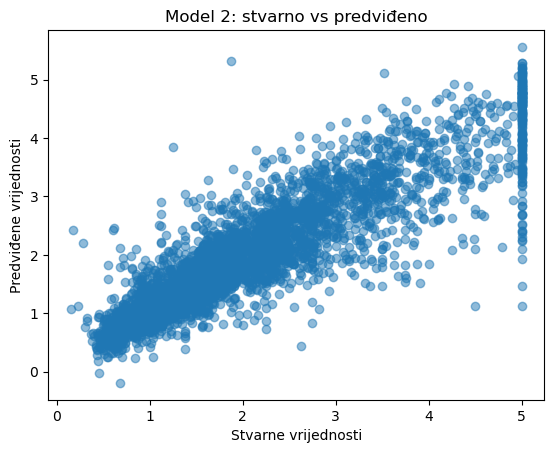

In [24]:
plt.scatter(y_test, y2, alpha=0.5)
plt.xlabel("Stvarne vrijednosti")
plt.ylabel("Predviđene vrijednosti")
plt.title("Model 2: stvarno vs predviđeno")
plt.show()

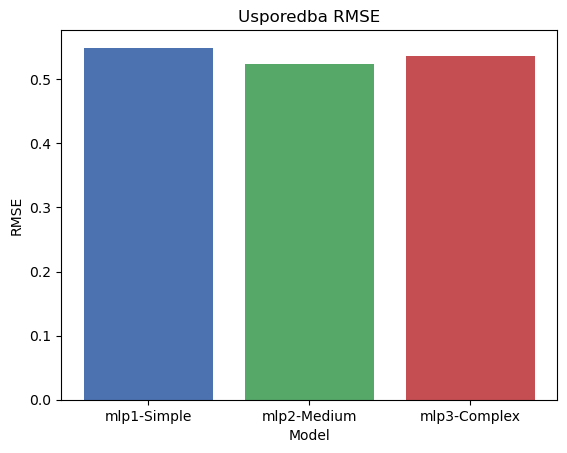

In [36]:
plt.bar(rez["Model"], rez["RMSE"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Usporedba RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

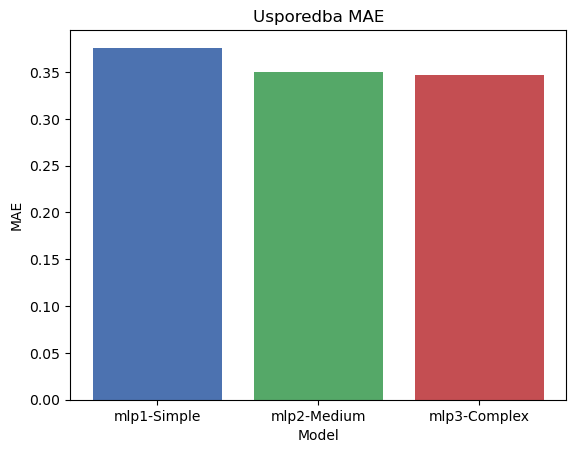

In [32]:
plt.bar(rez["Model"], rez["MAE"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Usporedba MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

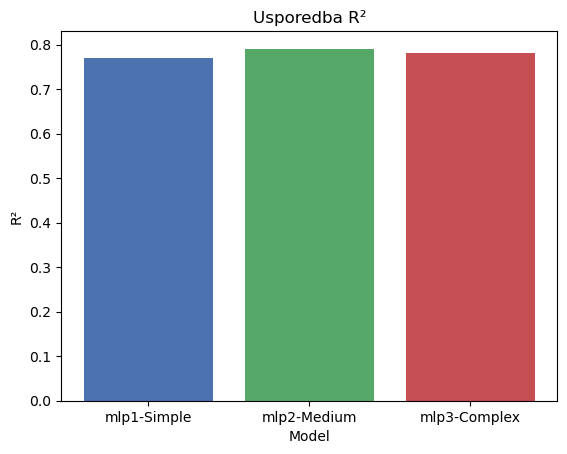

In [33]:
plt.bar(rez["Model"], rez["R2"], color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Usporedba R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.show()

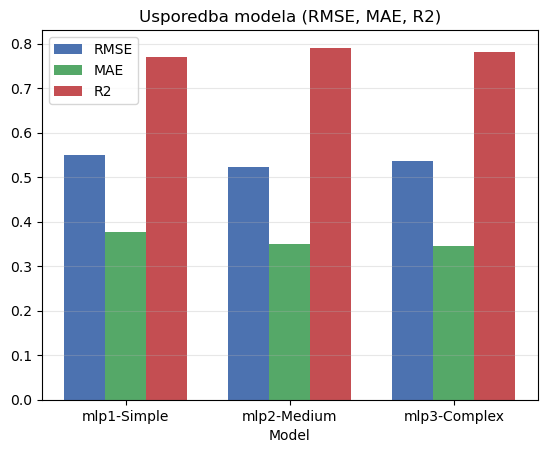

In [37]:
x = np.arange(len(rez["Model"]))
width = 0.25

plt.bar(x - width, rez["RMSE"], width, label="RMSE", color="#4C72B0")
plt.bar(x, rez["MAE"], width, label="MAE", color="#55A868")
plt.bar(x + width, rez["R2"], width, label="R2", color="#C44E52")

plt.xticks(x, rez["Model"])
plt.title("Usporedba modela (RMSE, MAE, R2)")
plt.xlabel("Model")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

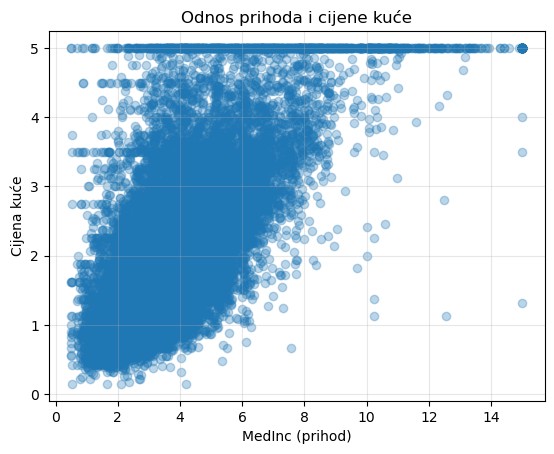

In [35]:
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.3)
plt.xlabel("MedInc (prihod)")
plt.ylabel("Cijena kuće")
plt.title("Odnos prihoda i cijene kuće")
plt.grid(True, alpha=0.3)
plt.show()